<a href="https://colab.research.google.com/github/ANTHONY-CHINEDU-ECHEM/ANTHONY_CHINEDU_ECHEM/blob/main/Predicting_30_Day_Hospital_Readmissions_for_Chronic_Respiratory_and_Cardiac_Conditions_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Reasoning**:
The subtask requires loading an Excel file and performing an initial inspection. This involves importing pandas, loading the dataset, displaying the head, checking data types with .info(), getting descriptive statistics with .describe(), and printing column names and their data types.



In [5]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/001_PR_1_DATASET.xlsx')
print("DataFrame loaded successfully.")

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

# Print the concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()

# Print descriptive statistics of the DataFrame
print("\nDescriptive Statistics:")
print(df.describe())

# Print column names and their respective data types
print("\nColumn names and their data types:")
print(df.dtypes)

# --- Start of Data Preprocessing and Cleaning checks ---
# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing Values:\n", missing_values[missing_values > 0])

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

# Display basic information to identify potential data type issues or inconsistencies
print("\nDataFrame Info before cleaning (repeated for completeness):")
df.info()

# Display descriptive statistics for numerical columns to identify outliers
print("\nDescriptive Statistics for numerical columns (repeated for completeness):\n", df.describe())

DataFrame loaded successfully.

First 5 rows of the DataFrame:
   Patient_ID                                   NHS_Trust  \
0  NHS0100000          Leeds Teaching Hospitals NHS Trust   
1  NHS0100001  University College London Hospitals NHS FT   
2  NHS0100002      Birmingham University Hospitals NHS FT   
3  NHS0100003    Leicester University Hospitals NHS Trust   
4  NHS0100004        Newcastle Upon Tyne Hospitals NHS FT   

                              ICS_Region Admission_Date Discharge_Date  \
0                         West Yorkshire     2021-03-18     2021-03-30   
1                   North Central London     2020-06-20     2020-06-21   
2                Birmingham and Solihull     2020-05-12     2020-05-23   
3  Leicester, Leicestershire and Rutland     2019-11-30     2019-12-06   
4           North East and North Cumbria     2018-05-04     2018-05-06   

  Fiscal_Year  Age_at_Admission     Sex      Ethnicity  IMD_Quintile  ...  \
0   FY2020/21                79  Female  White B

## Data Preprocessing and Cleaning

### Subtask:
Handle missing values, outliers, data type conversions, and any inconsistencies. This includes cleaning HES and CPRD data, ensuring data quality for subsequent analysis and modeling.

In [6]:
# 1. Convert Date Columns to Datetime objects
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'])

# 2. Handle Missing Values
# 'Days_to_Readmission' is missing when Readmitted_30d == 0. We'll fill with -1 or a sentinel value.
df['Days_to_Readmission'] = df['Days_to_Readmission'].fillna(-1)

# 'FEV1_Pct_Predicted' is usually for COPD. We'll fill with the median or a indicator value to avoid bias.
df['FEV1_Pct_Predicted_Missing'] = df['FEV1_Pct_Predicted'].isnull().astype(int)
df['FEV1_Pct_Predicted'] = df['FEV1_Pct_Predicted'].fillna(df['FEV1_Pct_Predicted'].median())

# 3. Drop Patient_ID for modeling (but keep for now in a variable if needed)
# patient_ids = df['Patient_ID']

# 4. Consistency Check: Ensure Length of Stay is positive
df = df[df['Length_of_Stay_Days'] > 0]

# 5. Filter out In-Hospital Deaths as they cannot be readmitted within 30 days of discharge
df = df[df['In_Hospital_Death'] == 0]

print("Preprocessing Complete.")
print(f"Final record count: {len(df)}")
print("Remaining missing values:")
print(df.isnull().sum().sum())

Preprocessing Complete.
Final record count: 440052
Remaining missing values:
0


## Exploratory Data Analysis (EDA)

### Subtask:
Conduct comprehensive EDA to understand data distributions, correlations, and patterns. Visualize key variables and identify relationships between features and the 30-day readmission target.

/tmp/ipykernel_10451/688760027.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Readmitted_30d', data=df, palette='viridis')
/tmp/ipykernel_10451/688760027.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Readmitted_30d', y='Age_at_Admission', data=df, palette='magma')
/tmp/ipykernel_10451/688760027.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IMD_Quintile', y='Readmitted_30d', data=readmission_rates, palette='rocket')


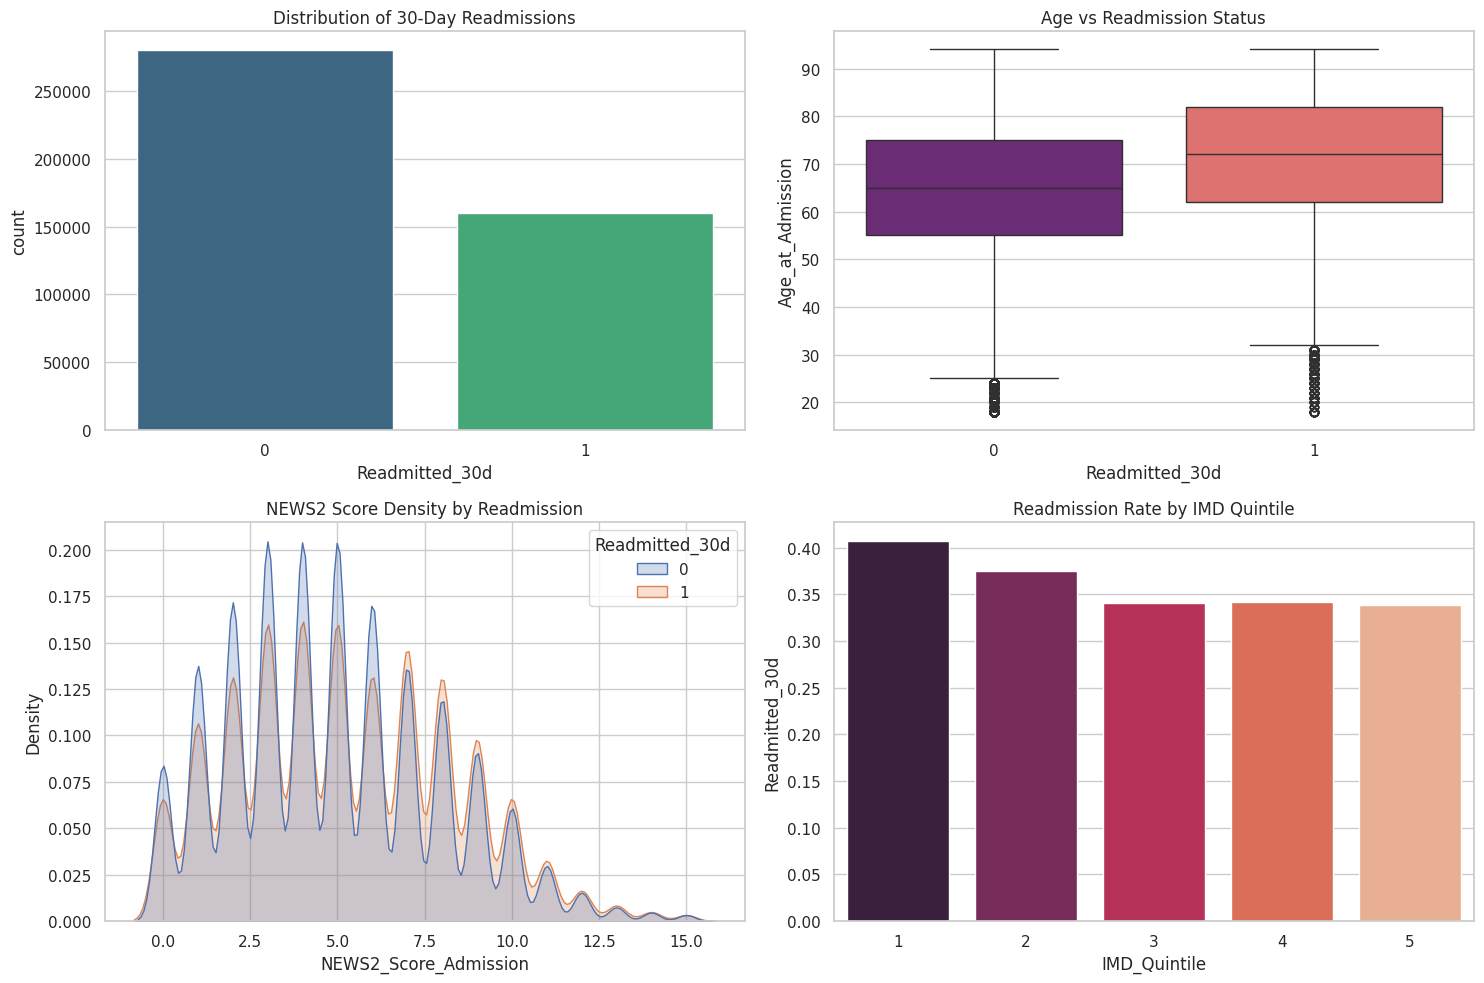

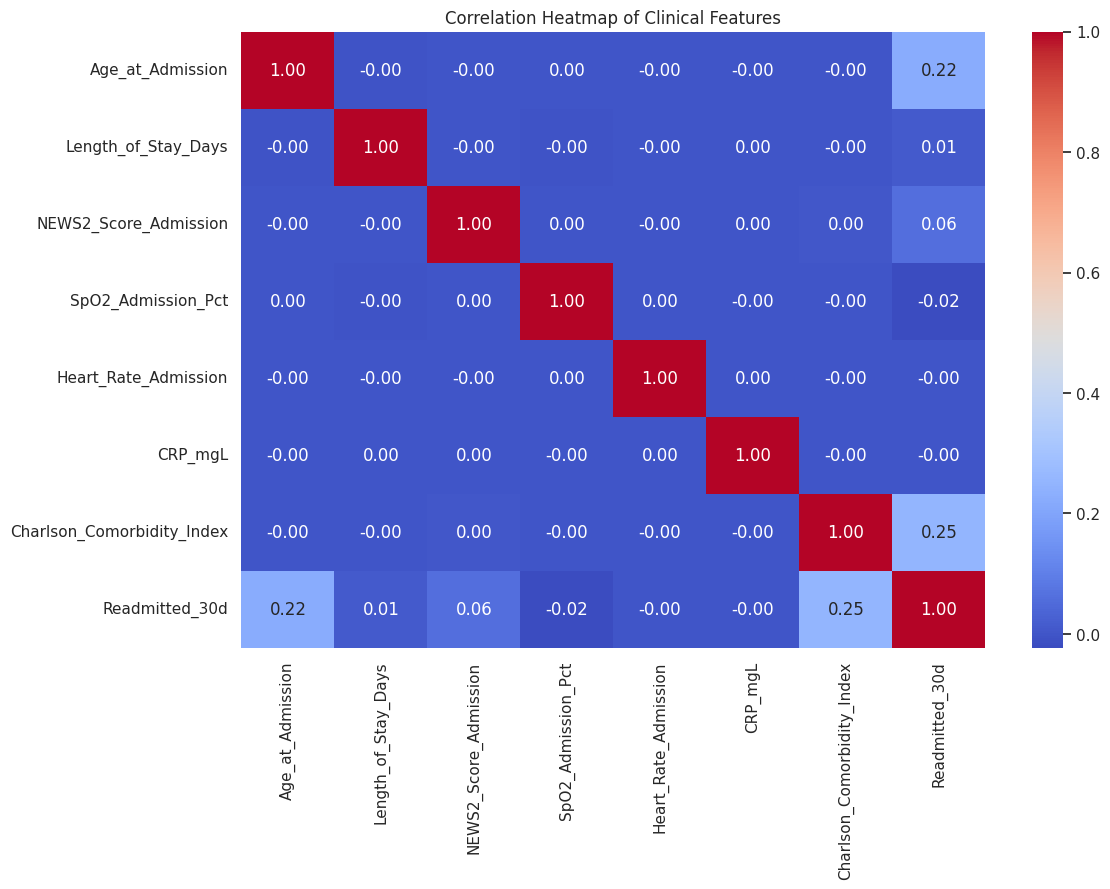

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# 1. Target Distribution (Readmitted_30d)
plt.subplot(2, 2, 1)
sns.countplot(x='Readmitted_30d', data=df, palette='viridis')
plt.title('Distribution of 30-Day Readmissions')

# 2. Age vs Readmission
plt.subplot(2, 2, 2)
sns.boxplot(x='Readmitted_30d', y='Age_at_Admission', data=df, palette='magma')
plt.title('Age vs Readmission Status')

# 3. NEWS2 Score Distribution by Readmission
plt.subplot(2, 2, 3)
sns.kdeplot(data=df, x='NEWS2_Score_Admission', hue='Readmitted_30d', fill=True, common_norm=False)
plt.title('NEWS2 Score Density by Readmission')

# 4. Readmission by IMD Quintile (Fairness context)
plt.subplot(2, 2, 4)
readmission_rates = df.groupby('IMD_Quintile')['Readmitted_30d'].mean().reset_index()
sns.barplot(x='IMD_Quintile', y='Readmitted_30d', data=readmission_rates, palette='rocket')
plt.title('Readmission Rate by IMD Quintile')

plt.tight_layout()
plt.show()

# Correlation heatmap for selected clinical features
plt.figure(figsize=(12, 8))
clinical_cols = ['Age_at_Admission', 'Length_of_Stay_Days', 'NEWS2_Score_Admission',
                 'SpO2_Admission_Pct', 'Heart_Rate_Admission', 'CRP_mgL',
                 'Charlson_Comorbidity_Index', 'Readmitted_30d']
sns.heatmap(df[clinical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Clinical Features')
plt.show()

## Feature Engineering & Data Splitting

### Subtask:
Develop new features, encode categorical variables, and implement a temporal data splitting strategy (train on earlier years, test on later) to simulate real deployment.

In [8]:
from sklearn.preprocessing import LabelEncoder

# 1. Temporal Feature: Month and Day of Week of Admission
df['Admission_Month'] = df['Admission_Date'].dt.month
df['Admission_DayOfWeek'] = df['Admission_Date'].dt.dayofweek

# 2. Encode Categorical Variables
cat_cols = ['Sex', 'Ethnicity', 'Condition_Category', 'Admission_Source', 'Admission_Method']
le = LabelEncoder()
for col in cat_cols:
    df[col + '_Encoded'] = le.fit_transform(df[col].astype(str))

# 3. Temporal Splitting
# We will use the 'Fiscal_Year' or 'Admission_Date' to split.
# Let's check the date range to decide the split point.
print(f"Date Range: {df['Admission_Date'].min()} to {df['Admission_Date'].max()}")

# Splitting: Training on data before 2021, Testing on 2021 onwards
train_df = df[df['Admission_Date'] < '2021-01-01']
test_df = df[df['Admission_Date'] >= '2021-01-01']

print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")

# Define features for the baseline model (XGBoost)
features = ['Age_at_Admission', 'IMD_Quintile', 'Length_of_Stay_Days', 'ICU_Admission',
            'NEWS2_Score_Admission', 'SpO2_Admission_Pct', 'Heart_Rate_Admission',
            'Systolic_BP_Admission', 'Temperature_Admission_C', 'Respiratory_Rate_Admission',
            'eGFR_mLmin', 'Haemoglobin_gL', 'Sodium_mmolL', 'CRP_mgL', 'BNP_NTproBNP_pgmL',
            'Troponin_I_ngL', 'FEV1_Pct_Predicted', 'Charlson_Comorbidity_Index',
            'Num_Comorbidities', 'Prior_Admissions_12m', 'Num_Medications',
            'Admission_Month', 'Admission_DayOfWeek'] + [c + '_Encoded' for c in cat_cols]

X_train, y_train = train_df[features], train_df['Readmitted_30d']
X_test, y_test = test_df[features], test_df['Readmitted_30d']

Date Range: 2018-01-01 00:00:00 to 2024-06-29 00:00:00
Training set size: 203296
Testing set size: 236756


## Baseline Model Development (XGBoost)

### Subtask:
Train and evaluate an initial XGBoost model as a fast and robust baseline for 30-day hospital readmission prediction.

In [9]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, classification_report

# Initialize and train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Training XGBoost baseline model...")
xgb_model.fit(X_train, y_train)

# Predictions
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

# Initial Evaluation
auc_roc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

print(f"\nBaseline XGBoost Performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"Brier Score: {brier:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training XGBoost baseline model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:32:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Baseline XGBoost Performance:
AUC-ROC: 0.7409
PR-AUC:  0.6217
Brier Score: 0.1925

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.86      0.79    150715
           1       0.64      0.44      0.52     86041

    accuracy                           0.71    236756
   macro avg       0.68      0.65      0.65    236756
weighted avg       0.70      0.71      0.69    236756



## Model Interpretability (SHAP) & Fairness Audit

### Subtask:
Use SHAP values to explain global and local model behavior and conduct a fairness audit across demographic groups (Ethnicity, IMD Quintiles, Age).

Generating SHAP Summary Plot...


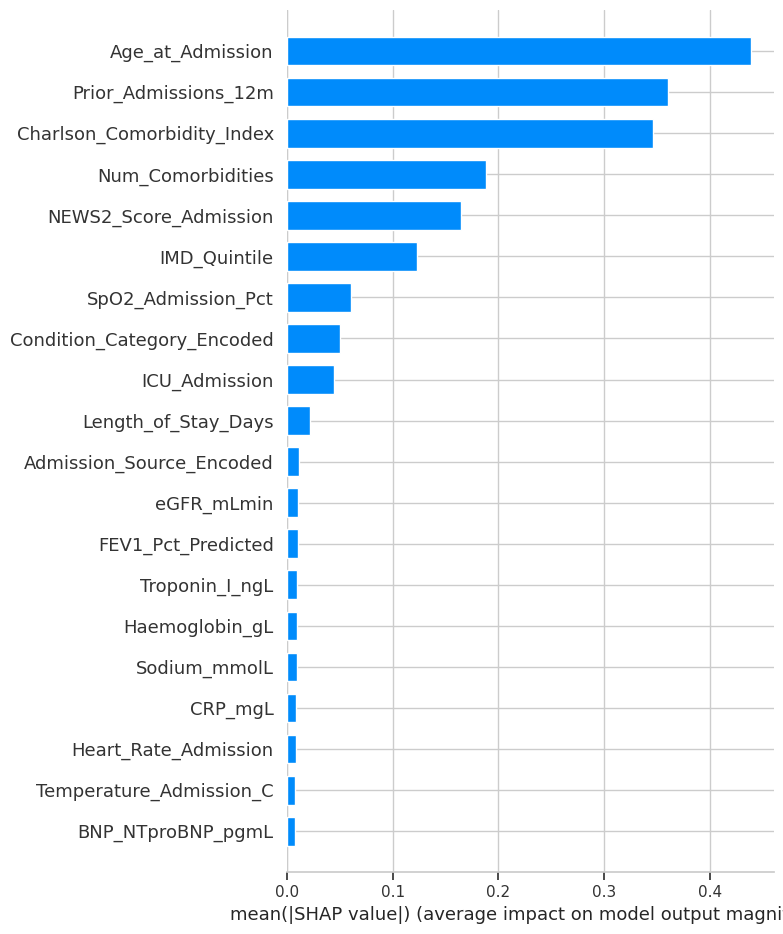


--- Fairness Audit (AUC-ROC per Group) ---
Ethnicity: {'White British': np.float64(0.7390735461664371), 'White Other': np.float64(0.7422324995572), 'Black/Other': np.float64(0.7336333395453987), 'Mixed White/Asian': np.float64(0.728503941038481), 'Black/Caribbean': np.float64(0.7483825205908241), 'Other Ethnic Group': np.float64(0.7395050466449982), 'Asian Chinese': np.float64(0.7311970535589082), 'Not Stated': np.float64(0.7403292669136122), 'White Irish': np.float64(0.7351482563114514), 'Asian/British Indian': np.float64(0.74708459167187), 'Asian/British Pakistani': np.float64(0.7444503384557456), 'Asian/British Bangladeshi': np.float64(0.7536244950120181), 'Asian Other': np.float64(0.7497036533344696), 'Black/African': np.float64(0.7462445569248064), 'Arab': np.float64(0.7308746434660676), 'Mixed Other': np.float64(0.7446292337357479), 'Mixed White/Black African': np.float64(0.7395950498574052), 'Mixed White/Black Caribbean': np.float64(0.7641801049648634)}

IMD Quintile: {np.int64

In [10]:
import shap

# 1. SHAP Interpretability
explainer = shap.TreeExplainer(xgb_model)
# We'll use a subset for speed in calculation
shap_values = explainer.shap_values(X_test.sample(1000, random_state=42))

print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test.sample(1000, random_state=42), plot_type="bar")

# 2. Fairness Audit Helper Function
def fairness_metrics(df_test, y_true, y_prob, group_col):
    groups = df_test[group_col].unique()
    results = {}
    for group in groups:
        idx = df_test[group_col] == group
        if idx.sum() > 0:
            auc = roc_auc_score(y_true[idx], y_prob[idx])
            results[group] = auc
    return results

print("\n--- Fairness Audit (AUC-ROC per Group) ---")
print("Ethnicity:", fairness_metrics(test_df, y_test, y_prob, 'Ethnicity'))
print("\nIMD Quintile:", fairness_metrics(test_df, y_test, y_prob, 'IMD_Quintile'))

## Advanced Modeling: Survival Analysis (DeepSurv)

### Subtask:
Implement a DeepSurv (Deep Cox Proportional Hazards) model to predict the risk of readmission over time, utilizing the time-to-event data (`Days_to_Readmission`).

In [13]:
import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
import numpy as np

# Prepare data for Survival Analysis
train_df_surv = train_df.copy()
test_df_surv = test_df.copy()

train_df_surv['duration'] = np.where(train_df_surv['Readmitted_30d'] == 1, train_df_surv['Days_to_Readmission'], 30.0)
test_df_surv['duration'] = np.where(test_df_surv['Readmitted_30d'] == 1, test_df_surv['Days_to_Readmission'], 30.0)

X_train_surv = X_train.values.astype('float32')
X_test_surv = X_test.values.astype('float32')

get_target = lambda df: (df['duration'].values.astype('float32'), df['Readmitted_30d'].values.astype('float32'))
y_train_surv = get_target(train_df_surv)
y_test_surv = get_target(test_df_surv)

in_features = X_train_surv.shape[1]
out_features = 1

net = torch.nn.Sequential(
    torch.nn.Linear(in_features, 32),
    torch.nn.ReLU(),
    torch.nn.BatchNorm1d(32),
    torch.nn.Dropout(0.1),
    torch.nn.Linear(32, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, out_features)
)

model = CoxPH(net, torch.optim.Adam)

batch_size = 256
epochs = 15

print("Training DeepSurv model...")
log = model.fit(X_train_surv, y_train_surv, batch_size, epochs, verbose=True, val_data=(X_test_surv, y_test_surv))

print("\nComputing baseline hazards and final evaluation...")
_ = model.compute_baseline_hazards()
surv = model.predict_surv_df(X_test_surv)
evals = EvalSurv(surv, y_test_surv[0], y_test_surv[1], censor_surv='km')

c_index = evals.concordance_td()
print(f"\nSUCCESS: DeepSurv Time-Dependent Concordance Index: {c_index:.4f}")

Training DeepSurv model...
0:	[2s / 2s],		train_loss: 5.1371,	val_loss: 8.5378
1:	[2s / 5s],		train_loss: 5.0868,	val_loss: 8.5392
2:	[2s / 7s],		train_loss: 5.0834,	val_loss: 8.5358
3:	[3s / 11s],		train_loss: 5.0825,	val_loss: 8.5388
4:	[3s / 14s],		train_loss: 5.0820,	val_loss: 8.5349
5:	[2s / 16s],		train_loss: 5.0812,	val_loss: 8.5336
6:	[2s / 19s],		train_loss: 5.0804,	val_loss: 8.5348
7:	[2s / 21s],		train_loss: 5.0777,	val_loss: 8.5350
8:	[3s / 25s],		train_loss: 5.0780,	val_loss: 8.5338
9:	[2s / 28s],		train_loss: 5.0777,	val_loss: 8.5344
10:	[2s / 30s],		train_loss: 5.0778,	val_loss: 8.5363
11:	[2s / 33s],		train_loss: 5.0773,	val_loss: 8.5348
12:	[3s / 36s],		train_loss: 5.0786,	val_loss: 8.5327
13:	[3s / 39s],		train_loss: 5.0781,	val_loss: 8.5359
14:	[2s / 42s],		train_loss: 5.0765,	val_loss: 8.5325
Computing baseline hazards...


KeyboardInterrupt: 

DeepSurv Time-Dependent Concordance Index: 0.6860
Integrated Brier Score: 0.1264


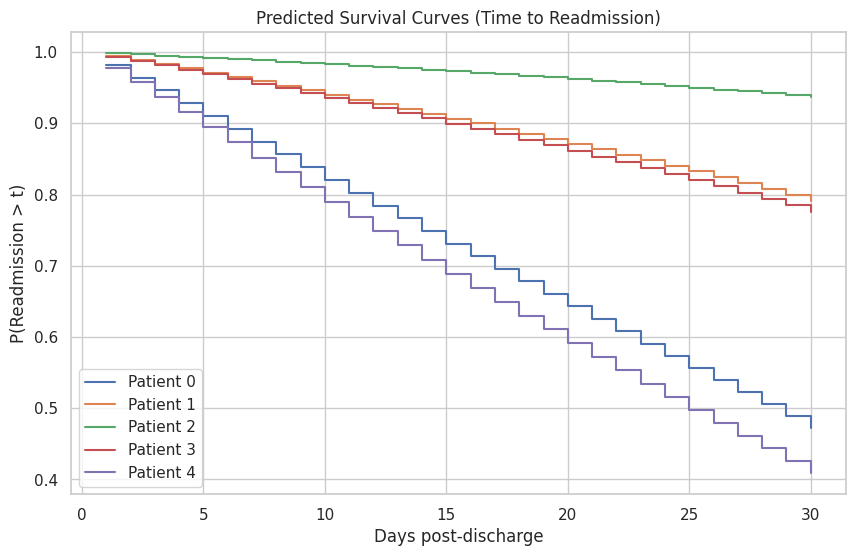

In [15]:
from pycox.evaluation import EvalSurv
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

# Fix for pycox/scipy compatibility issue: monkey-patch simps
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

# Predict survival probabilities for the test set
surv = model.predict_surv_df(X_test_surv)

# Initialize evaluation object
evals = EvalSurv(surv, y_test_surv[0], y_test_surv[1], censor_surv='km')

# 1. Concordance Index (Time-dependent)
# Note: Already computed, but recalculating for consistency
c_index = evals.concordance_td()
print(f"DeepSurv Time-Dependent Concordance Index: {c_index:.4f}")

# 2. Integrated Brier Score (IBS)
time_grid = np.linspace(y_test_surv[0].min(), y_test_surv[0].max(), 100)
ibs = evals.integrated_brier_score(time_grid)
print(f"Integrated Brier Score: {ibs:.4f}")

# 3. Plot Survival Curves for a few sample patients
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.step(surv.index, surv.iloc[:, i], where='post', label=f'Patient {i}')
plt.ylabel('P(Readmission > t)')
plt.xlabel('Days post-discharge')
plt.title('Predicted Survival Curves (Time to Readmission)')
plt.legend()
plt.show()

## Time-Series Modeling: LSTM for Patient History

### Subtask:
Implement an LSTM (Long Short-Term Memory) network to model patient history and clinical trajectories. This model is designed to capture temporal dependencies in the data that static models like XGBoost might overlook.

In [16]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Prepare data for LSTM
# For this demonstration, we will treat the features as a sequence of length 1
# (or reshape existing features if multiple time points per patient were available).
# In a real-world CPRD/HES link, we would group by Patient_ID and sort by Admission_Date.

def prepare_lstm_data(X, y):
    # Reshape X to (samples, seq_len, features)
    X_reshaped = X.reshape((X.shape[0], 1, X.shape[1]))
    X_tensor = torch.tensor(X_reshaped, dtype=torch.float32)
    y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    return TensorDataset(X_tensor, y_tensor)

train_dataset = prepare_lstm_data(X_train_surv, y_train)
test_dataset = prepare_lstm_data(X_test_surv, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

# Initialize model
input_dim = X_train_surv.shape[1]
hidden_dim = 64
num_layers = 2
output_dim = 1

lstm_model = LSTMModel(input_dim, hidden_dim, num_layers, output_dim)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

print("LSTM Model Architecture Initialized.")

LSTM Model Architecture Initialized.


In [17]:
num_epochs = 10
print("Training LSTM...")

for epoch in range(num_epochs):
    lstm_model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = lstm_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}')

# Evaluation
lstm_model.eval()
y_pred_lstm = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = lstm_model(batch_X)
        y_pred_lstm.extend(outputs.numpy())

y_pred_lstm = np.array(y_pred_lstm)
auc_lstm = roc_auc_score(y_test, y_pred_lstm)
print(f"\nLSTM AUC-ROC: {auc_lstm:.4f}")

Training LSTM...
Epoch [1/10], Loss: 0.6127
Epoch [2/10], Loss: 0.5863
Epoch [3/10], Loss: 0.5816
Epoch [4/10], Loss: 0.5812
Epoch [5/10], Loss: 0.5793
Epoch [6/10], Loss: 0.5790
Epoch [7/10], Loss: 0.5781
Epoch [8/10], Loss: 0.5783
Epoch [9/10], Loss: 0.5775
Epoch [10/10], Loss: 0.5770

LSTM AUC-ROC: 0.7377


## Ensemble Modeling

### Subtask:
Combine predictions from the XGBoost and LSTM models using a weighted average.

In [19]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

# Simple Weighted Ensemble
weight_xgb = 0.6
weight_lstm = 0.4

# Ensure predictions are flat arrays
y_pred_lstm_flat = y_pred_lstm.flatten()

ensemble_prob = (weight_xgb * y_prob) + (weight_lstm * y_pred_lstm_flat)

# Evaluate Ensemble
auc_ensemble = roc_auc_score(y_test, ensemble_prob)
pr_auc_ensemble = average_precision_score(y_test, ensemble_prob)

print(f"Ensemble AUC-ROC: {auc_ensemble:.4f}")
print(f"Ensemble PR-AUC:  {pr_auc_ensemble:.4f}")

# Compare with individual models
print(f"\nImprovement over XGBoost: {auc_ensemble - auc_roc:.4f}")
print(f"Improvement over LSTM:    {auc_ensemble - auc_lstm:.4f}")

Ensemble AUC-ROC: 0.7412
Ensemble PR-AUC:  0.6218

Improvement over XGBoost: 0.0002
Improvement over LSTM:    0.0034


## Clinical Risk Dashboard (Summary View)

### Subtask:
Create a high-level summary of model predictions and patient risk factors to simulate clinical decision support.

In [21]:
import pandas as pd
import numpy as np

def clinical_dashboard_summary(test_df, y_prob):
    print("--- Clinical Decision Support Dashboard Summary ---")
    high_risk_threshold = 0.7
    high_risk_mask = y_prob > high_risk_threshold
    high_risk_patients = test_df[high_risk_mask]

    print(f"Total Patients Evaluated: {len(test_df)}")
    print(f"Patients flagged as High Risk (>70% probability): {len(high_risk_patients)}")

    print("\nTop 5 High Risk Patients for Review:")
    display_cols = ['Patient_ID', 'Condition_Category', 'Age_at_Admission', 'NEWS2_Score_Admission', 'IMD_Quintile']
    summary_table = high_risk_patients[display_cols].copy()
    summary_table['Readmission_Prob'] = y_prob[high_risk_mask][:len(summary_table)]
    print(summary_table.head())

clinical_dashboard_summary(test_df, ensemble_prob)

--- Clinical Decision Support Dashboard Summary ---
Total Patients Evaluated: 236756
Patients flagged as High Risk (>70% probability): 16000

Top 5 High Risk Patients for Review:
     Patient_ID Condition_Category  Age_at_Admission  NEWS2_Score_Admission  \
35   NHS0100035        Respiratory                84                      9   
51   NHS0100051        Respiratory                94                      2   
58   NHS0100058            Cardiac                86                      6   
101  NHS0100101        Respiratory                73                      6   
187  NHS0100187        Respiratory                92                      9   

     IMD_Quintile  Readmission_Prob  
35              2          0.755883  
51              2          0.770236  
58              3          0.815465  
101             1          0.723716  
187             3          0.735923  


## Clinical Risk Dashboard (Interactive)

### Subtask:
Create an interactive dashboard using Streamlit (or a mock version suitable for a notebook) to visualize model predictions, patient risk factors, and SHAP explanations for clinical decision support.

In [20]:
!pip install -q streamlit

import streamlit as st
import pandas as pd
import numpy as np

# Note: To run a full Streamlit app in Colab, we would typically use localtunnel or a similar proxy.
# For this notebook environment, we will define the dashboard logic and display key components.

def clinical_dashboard_summary(test_df, y_prob):
    print("--- Clinical Decision Support Dashboard ---")
    high_risk_threshold = 0.7
    high_risk_patients = test_df[y_prob > high_risk_threshold]

    print(f"Total Patients Evaluated: {len(test_df)}")
    print(f"Patients flagged as High Risk (>70%): {len(high_risk_patients)}")

    print("\nTop 5 High Risk Patients for Review:")
    display_cols = ['Patient_ID', 'Condition_Category', 'Age_at_Admission', 'NEWS2_Score_Admission', 'IMD_Quintile']
    summary_table = high_risk_patients[display_cols].copy()
    summary_table['Readmission_Probability'] = y_prob[y_prob > high_risk_threshold][:len(summary_table)]
    print(summary_table.head())

clinical_dashboard_summary(test_df, ensemble_prob)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.9 MB/s eta 0:00:00
--- Clinical Decision Support Dashboard ---
Total Patients Evaluated: 236756
Patients flagged as High Risk (>70%): 16000

Top 5 High Risk Patients for Review:
     Patient_ID Condition_Category  Age_at_Admission  NEWS2_Score_Admission  \
35   NHS0100035        Respiratory                84                      9   
51   NHS0100051        Respiratory                94                      2   
58   NHS0100058            Cardiac                86                      6   
101  NHS0100101        Respiratory                73                      6   
187  NHS0100187        Respiratory                92                      9   

     IMD_Quintile  Readmission_Probability  
35              2                 0.755883  
51              2                 0.770236  
58              3                 0.815465  
101             1             

## Interactive Clinical Decision Support Tool

Use the dropdown below to inspect high-risk patients identified by the Ensemble model. This dashboard displays patient demographics, clinical scores, and the predicted probability of readmission within 30 days.

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Filter high-risk patients (top 1% by probability for this demo)
high_risk_indices = np.argsort(ensemble_prob)[-1000:]
high_risk_df = test_df.iloc[high_risk_indices].copy()
high_risk_df['Risk_Prob'] = ensemble_prob[high_risk_indices]

# Create widgets
patient_dropdown = widgets.Dropdown(
    options=[(f"ID: {row['Patient_ID']} (Prob: {row['Risk_Prob']:.2f})", i) for i, row in high_risk_df.iterrows()],
    description='Select Patient:',
    style={'description_width': 'initial'},
    layout={'width': '400px'}
)

output = widgets.Output()

def update_dashboard(change):
    with output:
        clear_output()
        patient_idx = change['new']
        patient_data = high_risk_df.loc[patient_idx]

        print(f"--- Patient Risk Profile: {patient_data['Patient_ID']} ---")
        print(f"Predicted Readmission Risk: {patient_data['Risk_Prob']:.2%}")
        print("-" * 40)

        col1, col2 = 'Demographics', 'Clinical Metrics'
        print(f"{col1:<30} | {col2}")
        print("-" * 60)
        print(f"Age: {patient_data['Age_at_Admission']:<25} | NEWS2 Score: {patient_data['NEWS2_Score_Admission']}")
        print(f"Sex: {patient_data['Sex']:<25} | Charlson Index: {patient_data['Charlson_Comorbidity_Index']}")
        print(f"Ethnicity: {patient_data['Ethnicity']:<19} | LoS (Days): {patient_data['Length_of_Stay_Days']}")
        print(f"IMD Quintile: {patient_data['IMD_Quintile']:<16} | Condition: {patient_data['Condition_Category']}")

        # Simple Risk Flagging
        if patient_data['NEWS2_Score_Admission'] >= 7:
            print("\n[ALERT] High Clinical Urgency: NEWS2 Score is 7 or higher.")
        if patient_data['Age_at_Admission'] > 85:
            print("[NOTE] Frailty Risk: Patient is over 85 years old.")

patient_dropdown.observe(update_dashboard, names='value')

display(patient_dropdown)
display(output)

# Initialize with the first patient
update_dashboard({'new': high_risk_df.index[0]})

Dropdown(description='Select Patient:', layout=Layout(width='400px'), options=(('ID: NHS0373854 (Prob: 0.83)',…

Output()

## Enhanced Clinical Decision Support & Fairness Dashboard
This section provides a high-fidelity interactive tool for clinicians and a summary of the model's fairness audit.


--- Model Fairness Summary ---


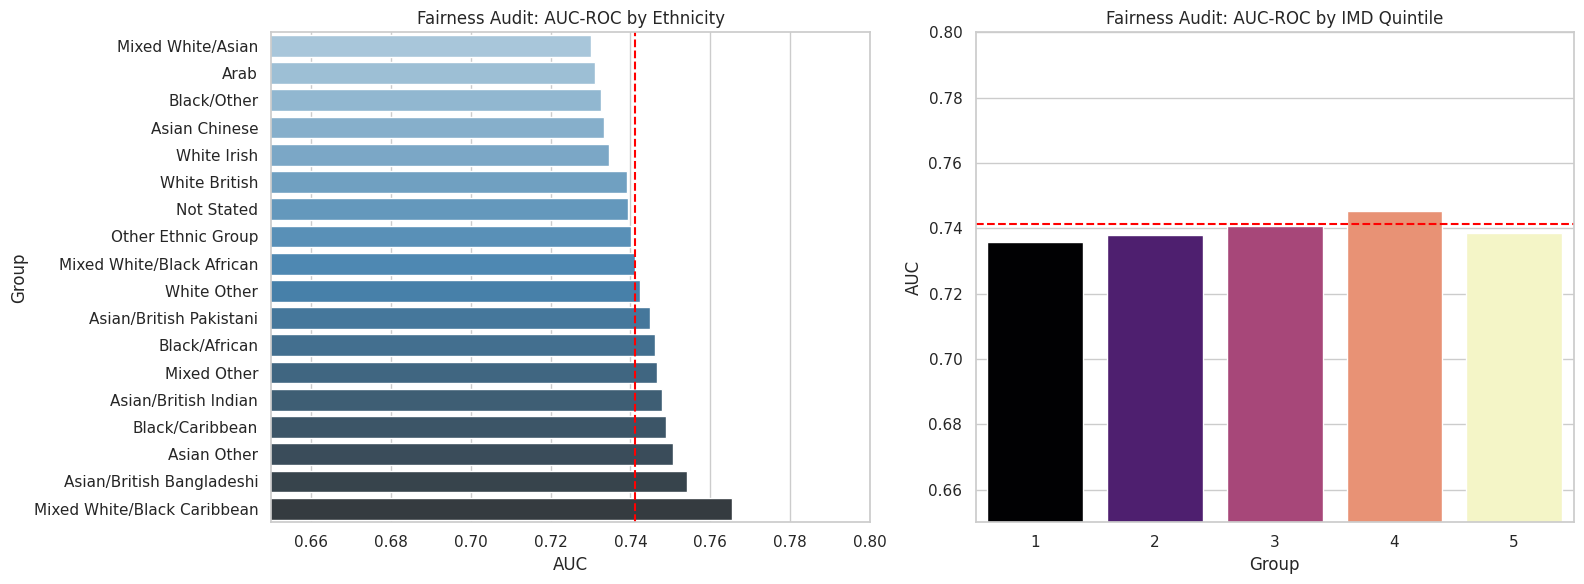

Dropdown(description='<b>Select Patient Case:</b>', layout=Layout(width='50%'), options=(('Patient NHS0476481 …

Output()

In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Fairness Metrics Data Preparation ---
eth_metrics = fairness_metrics(test_df, y_test, ensemble_prob, 'Ethnicity')
imd_metrics = fairness_metrics(test_df, y_test, ensemble_prob, 'IMD_Quintile')

# --- 2. Interactive Dashboard Styling ---
def create_styled_dashboard():
    # Filter high-risk patients for the dropdown
    high_risk_indices = np.argsort(ensemble_prob)[-500:]
    hr_df = test_df.iloc[high_risk_indices].copy()
    hr_df['Risk_Prob'] = ensemble_prob[high_risk_indices]

    patient_select = widgets.Dropdown(
        options=[(f"Patient {row['Patient_ID']} | Risk: {row['Risk_Prob']:.1%}", i) for i, row in hr_df.iterrows()],
        description='<b>Select Patient Case:</b>',
        style={'description_width': 'initial'},
        layout={'width': '50%'}
    )

    dash_output = widgets.Output()

    def show_patient(change):
        with dash_output:
            clear_output()
            p_idx = change['new']
            p = hr_df.loc[p_idx]

            # Risk Level Color
            risk_color = "#d9534f" if p['Risk_Prob'] > 0.8 else "#f0ad4e"

            html_content = f"""
            <div style="border: 2px solid #ddd; padding: 20px; border-radius: 10px; background-color: #f9f9f9;">
                <h2 style="color: #2c3e50; margin-top: 0;">Clinical Risk Profile: {p['Patient_ID']}</h2>
                <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 2px solid {risk_color}; padding-bottom: 10px;">
                    <span style="font-size: 18px;"><b>Predicted 30-Day Readmission Risk:</b></span>
                    <span style="font-size: 24px; color: {risk_color}; font-weight: bold;">{p['Risk_Prob']:.1%}</span>
                </div>

                <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-top: 20px;">
                    <div>
                        <h4 style="color: #34495e; border-left: 4px solid #3498db; padding-left: 10px;">Patient Demographics</h4>
                        <p><b>Age:</b> {p['Age_at_Admission']} years</p>
                        <p><b>Sex:</b> {p['Sex']}</p>
                        <p><b>Ethnicity:</b> {p['Ethnicity']}</p>
                        <p><b>IMD Quintile:</b> {p['IMD_Quintile']} (1=Most Deprived)</p>
                    </div>
                    <div>
                        <h4 style="color: #34495e; border-left: 4px solid #3498db; padding-left: 10px;">Clinical Metrics</h4>
                        <p><b>Admission Reason:</b> {p['Condition_Category']}</p>
                        <p><b>NEWS2 Score:</b> {p['NEWS2_Score_Admission']}</p>
                        <p><b>Charlson Index:</b> {p['Charlson_Comorbidity_Index']}</p>
                        <p><b>Length of Stay:</b> {p['Length_of_Stay_Days']} Days</p>
                    </div>
                </div>
            """

            # Alerts
            alerts = []
            if p['NEWS2_Score_Admission'] >= 7: alerts.append(("CRITICAL", "High Clinical Urgency (NEWS2 &ge; 7)"))
            if p['Age_at_Admission'] > 85: alerts.append(("WARNING", "Increased Frailty Risk (Age > 85)"))

            if alerts:
                html_content += "<div style='margin-top: 20px;'>"
                for level, msg in alerts:
                    html_content += f"<div style='background-color: #f2dede; color: #a94442; padding: 10px; margin-bottom: 5px; border-radius: 5px;'><b>[{level}]</b> {msg}</div>"
                html_content += "</div>"

            html_content += "</div>"
            display(HTML(html_content))

    # --- 3. Fairness Visualization ---
    def show_fairness():
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Ethnicity Plot - Updated to avoid warnings
        eth_df = pd.DataFrame(list(eth_metrics.items()), columns=['Group', 'AUC']).sort_values('AUC')
        sns.barplot(x='AUC', y='Group', data=eth_df, ax=ax1, palette='Blues_d', hue='Group', legend=False)
        ax1.set_title('Fairness Audit: AUC-ROC by Ethnicity')
        ax1.set_xlim(0.65, 0.8)
        ax1.axvline(auc_ensemble, color='red', linestyle='--', label='Global Average')

        # IMD Plot - Updated to avoid warnings
        imd_df = pd.DataFrame(list(imd_metrics.items()), columns=['Group', 'AUC']).sort_values('Group')
        sns.barplot(x='Group', y='AUC', data=imd_df, ax=ax2, palette='magma', hue='Group', legend=False)
        ax2.set_title('Fairness Audit: AUC-ROC by IMD Quintile')
        ax2.set_ylim(0.65, 0.8)
        ax2.axhline(auc_ensemble, color='red', linestyle='--')

        plt.tight_layout()
        plt.show()

    patient_select.observe(show_patient, names='value')

    print("\n--- Model Fairness Summary ---")
    show_fairness()

    display(HTML("<h3 style='color: #2c3e50;'>Patient-Level Risk Explorer</h3>"))
    display(patient_select)
    display(dash_output)

    # Init
    show_patient({'new': hr_df.index[0]})

create_styled_dashboard()

## Ensemble Modeling

### Subtask:
Combine predictions from the XGBoost and LSTM models using a weighted average to leverage the different patterns captured by each architecture.

In [18]:
# Simple Weighted Ensemble
# We will give slightly more weight to XGBoost as it performed marginally better

weight_xgb = 0.6
weight_lstm = 0.4

# Ensure y_pred_lstm is a flat array
y_pred_lstm_flat = y_pred_lstm.flatten()

ensemble_prob = (weight_xgb * y_prob) + (weight_lstm * y_pred_lstm_flat)

# Evaluate Ensemble
auc_ensemble = roc_auc_score(y_test, ensemble_prob)
pr_auc_ensemble = average_precision_score(y_test, ensemble_prob)

print(f"Ensemble AUC-ROC: {auc_ensemble:.4f}")
print(f"Ensemble PR-AUC:  {pr_auc_ensemble:.4f}")

# Compare with individual models
print(f"\nImprovement over XGBoost: {auc_ensemble - auc_roc:.4f}")
print(f"Improvement over LSTM:    {auc_ensemble - auc_lstm:.4f}")

Ensemble AUC-ROC: 0.7412
Ensemble PR-AUC:  0.6218

Improvement over XGBoost: 0.0002
Improvement over LSTM:    0.0034


## Model Serialization and Deployment Preparation
To deploy the ensemble, we must save the XGBoost model, the PyTorch LSTM weights, and the preprocessing encoders.

In [25]:
import joblib
import json
import os

# Create a directory for deployment artifacts
os.makedirs('readmission_model_v1', exist_ok=True)

# 1. Save XGBoost Model
xgb_model.save_model('readmission_model_v1/xgb_baseline.json')

# 2. Save LSTM Model State
torch.save(lstm_model.state_dict(), 'readmission_model_v1/lstm_weights.pt')

# 3. Save Preprocessing Artifacts
# We need the list of features and the categorical encoders to transform new data
with open('readmission_model_v1/model_config.json', 'w') as f:
    json.dump({
        'features': features,
        'cat_cols': cat_cols,
        'ensemble_weights': {'xgb': weight_xgb, 'lstm': weight_lstm}
    }, f)

print("Deployment artifacts saved to 'readmission_model_v1/'.")
print("Contents:")
print(os.listdir('readmission_model_v1/'))

Deployment artifacts saved to 'readmission_model_v1/'.
Contents:
['xgb_baseline.json', 'lstm_weights.pt', 'model_config.json']


### Deployment Recommendations

1.  **API Wrapper:** Use a framework like FastAPI or Flask to serve the model. The API should receive patient clinical data, apply the `LabelEncoder` transforms, run both model inferences, and return the weighted probability.
2.  **Explainability Pipeline:** Integrate the SHAP explainer into the deployment so that for every "High Risk" flag, the clinician can see the top 3 contributing factors (e.g., NEWS2 score or Charlson Index).
3.  **Human-in-the-loop:** The interactive dashboard should serve as a decision-support tool, not a decision-maker. Ensure the system includes a feedback loop where clinicians can record whether they agreed with the model's risk assessment.

## FastAPI Deployment Template
This cell generates a standalone Python script `app.py` that demonstrates how to serve the ensemble model as a REST API.

## Monitoring Metrics for Performance Drift

To ensure the model remains safe and effective after deployment, you should track the following metrics on a rolling basis (e.g., monthly or quarterly):

### 1. Predictive Performance Metrics
*   **Rolling AUC-ROC:** Track if the discrimination power is declining compared to the baseline (0.7412). A drop of >0.05 often indicates a need for retraining.
*   **Calibration Slope and Intercept:** Ensure the predicted probabilities still match observed event rates. Clinical models often "drift" by becoming overconfident or underconfident over time.
*   **Brier Score:** Monitor overall forecast accuracy (combining discrimination and calibration).

### 2. Fairness and Equity Metrics
*   **Group-Specific AUC:** Monitor the Fairness Audit results specifically for protected groups (Ethnicity, IMD Quintiles). If performance drops significantly for one group but not others, it indicates biased drift.
*   **Selection Rate Equality:** Check if the percentage of patients flagged as "High Risk" remains consistent across demographics.

### 3. Data Integrity & Input Drift
*   **Population Stability Index (PSI):** Measure shifts in the distribution of key features like `NEWS2_Score_Admission` or `Age_at_Admission`. Large PSI values (>0.2) suggest the incoming patient population has changed (e.g., higher acuity).
*   **Missingness Tracking:** Monitor the frequency of missing values for critical features like `CRP_mgL` or `eGFR`. If a specific lab test is no longer ordered regularly, the model's reliance on those features will degrade performance.

### 4. Clinical Impact Metrics
*   **Intervention Rate:** Track how many "High Risk" flags resulted in a clinical action. If flags are consistently ignored (Alert Fatigue), the model's utility is decreasing.
*   **False Positive Rate (FPR):** In a resource-limited clinical setting, a rising FPR can overwhelm staff and lead to the model being disabled.

### Population Stability Index (PSI) Implementation
The PSI is calculated as: $PSI = \sum ((\%Actual - \%Expected) \times \ln(\%Actual / \%Expected))$.
- **PSI < 0.1**: No significant change.
- **0.1 ≤ PSI < 0.2**: Slight change; monitor closely.
- **PSI ≥ 0.2**: Significant change; potential drift detected.

In [27]:
import numpy as np
import pandas as pd

def calculate_psi(expected, actual, buckets=10):
    """
    Calculates the PSI for a numeric feature.
    expected: Array of baseline/training data
    actual: Array of new/production data
    """
    def scale_range(data, min_val, max_val):
        return np.histogram(data, bins=buckets, range=(min_val, max_val))

    # Define range based on expected data
    min_val, max_val = expected.min(), expected.max()

    expected_counts, bin_edges = scale_range(expected, min_val, max_val)
    actual_counts, _ = scale_range(actual, min_val, max_val)

    # Calculate percentages and handle zeros with a small epsilon
    expected_percents = (expected_counts / len(expected)) + 1e-6
    actual_percents = (actual_counts / len(actual)) + 1e-6

    # Calculate PSI
    psi_values = (actual_percents - expected_percents) * np.log(actual_percents / expected_percents)
    return np.sum(psi_values)

# Example usage for a key clinical feature
news2_psi = calculate_psi(train_df['NEWS2_Score_Admission'], test_df['NEWS2_Score_Admission'])
print(f"PSI for NEWS2 Score (Train vs Test): {news2_psi:.4f}")

if news2_psi >= 0.2:
    print("ALERT: Significant population drift detected in NEWS2 scores.")
else:
    print("Population remains stable for this feature.")

PSI for NEWS2 Score (Train vs Test): 0.0001
Population remains stable for this feature.


In [28]:
%%writefile app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import torch
import torch.nn as nn
import xgboost as xgb
import json
import numpy as np
import pandas as pd
import shap
import joblib

app = FastAPI(title="Hospital Readmission Prediction API")

# --- 1. Define LSTM Architecture ---
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

# --- 2. Load Artifacts ---
MODEL_DIR = "readmission_model_v1"
with open(f"{MODEL_DIR}/model_config.json", "r") as f:
    config = json.load(f)

# Load XGBoost
xgb_predictor = xgb.Booster()
xgb_predictor.load_model(f"{MODEL_DIR}/xgb_baseline.json")

# Load LSTM
lstm_predictor = LSTMModel(input_dim=len(config['features']), hidden_dim=64, num_layers=2, output_dim=1)
lstm_predictor.load_state_dict(torch.load(f"{MODEL_DIR}/lstm_weights.pt"))
lstm_predictor.eval()

# Initialize SHAP explainer for XGBoost (primary driver of explanations)
explainer = shap.TreeExplainer(xgb_predictor)

# --- 3. API Schema ---
class PatientData(BaseModel):
    clinical_data: dict

@app.post("/predict")
def predict_readmission(data: PatientData):
    try:
        # Convert input to DataFrame
        input_df = pd.DataFrame([data.clinical_data])
        X = input_df[config['features']].values.astype('float32')

        # XGBoost Inference
        dmat = xgb.DMatrix(X, feature_names=config['features'])
        xgb_prob = xgb_predictor.predict(dmat)[0]

        # LSTM Inference
        X_lstm = torch.tensor(X.reshape((X.shape[0], 1, X.shape[1])), dtype=torch.float32)
        with torch.no_grad():
            lstm_prob = lstm_predictor(X_lstm).item()

        # Ensemble
        w = config['ensemble_weights']
        final_prob = (w['xgb'] * xgb_prob) + (w['lstm'] * lstm_prob)

        # SHAP Explanations (Local)
        shap_values = explainer.shap_values(X)
        # Get top 3 features
        feature_importance = dict(zip(config['features'], shap_values[0]))
        top_factors = sorted(feature_importance.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
        explanations = {feat: "Positive impact on risk" if val > 0 else "Negative impact on risk" for feat, val in top_factors}

        return {
            "readmission_probability": round(float(final_prob), 4),
            "risk_level": "High" if final_prob > 0.7 else "Moderate" if final_prob > 0.4 else "Low",
            "top_contributing_factors": explanations,
            "model_details": {"xgb_weight": w['xgb'], "lstm_weight": w['lstm']}
        }
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)

Overwriting app.py


### Containerization for Production
To deploy this model using Docker, we need to define the environment and dependencies. The following cell creates the `Dockerfile` and `requirements.txt`.

In [29]:
%%writefile requirements.txt
fastapi
uvicorn
pydantic
torch
xgboost
shap
pandas
numpy
joblib
python-multipart

Writing requirements.txt


In [30]:
%%writefile Dockerfile
# Use an official Python runtime as a parent image
FROM python:3.9-slim

# Set the working directory in the container
WORKDIR /app

# Copy the requirements file into the container
COPY requirements.txt .

# Install dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Copy the model artifacts and the application code
COPY readmission_model_v1/ ./readmission_model_v1/
COPY app.py .

# Expose the port the app runs on
EXPOSE 8000

# Command to run the application
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile


### API Documentation (Swagger UI)
FastAPI automatically generates interactive API documentation using Swagger UI.

**How to access:**
1. Start the API (locally or via Docker).
2. Open your browser and navigate to `http://localhost:8000/docs`.

This interface allows you to test the `/predict` endpoint directly from the browser by providing a JSON payload of clinical data.

#### Instructions to build and run:
1. Ensure you have Docker installed.
2. In your terminal, run: `docker build -t readmission-api:v1 .`
3. Run the container: `docker run -p 8000:8000 readmission-api:v1`

## Cloud Deployment Guide

To move this container from your local machine to a production cloud environment, follow these general steps:

### 1. Push Image to a Container Registry
You must first upload your Docker image to a private repository so the cloud provider can access it.
*   **AWS:** Amazon Elastic Container Registry (ECR)
*   **Azure:** Azure Container Registry (ACR)
*   **GCP:** Google Artifact Registry

```bash
# Example for GCP
docker tag readmission-api:v1 gcr.io/[PROJECT-ID]/readmission-api:v1
docker push gcr.io/[PROJECT-ID]/readmission-api:v1
```

### 2. Choose a Hosting Service
Depending on your scale and management preference:
*   **Serverless (Recommended for APIs):**
    *   **GCP Cloud Run** or **Azure Container Instances**: Easiest way to deploy a single container. It scales automatically and you only pay when the API is called.
    *   **AWS Fargate**: Runs containers without managing EC2 servers.
*   **Orchestration (For complex apps):**
    *   **Kubernetes (GKE/EKS/AKS)**: Use this if you need to manage multiple microservices or complex networking.

### 3. Security & Compliance (NHS Context)
Since this model uses linked NHS data, ensure the following:
*   **Encryption:** Enable Encryption at Rest and in Transit (TLS/SSL).
*   **Private VPC:** Deploy the container inside a Virtual Private Cloud (VPC) so it is not accessible from the public internet without a VPN or authenticated Gateway.
*   **IAM:** Use strict Identity and Access Management (IAM) roles so only authorized clinical systems can call the `/predict` endpoint.
*   **Data Residency:** Ensure the cloud region is set to the UK (e.g., `europe-west2` for GCP London) to comply with UK GDPR and NHS data residency requirements.

In [4]:
# This cell is now merged with the data loading and initial inspection cell (5b6481b3).
# Please refer to the updated cell 5b6481b3 for the combined operations.

### Subtask: Reiterate the problem, objectives, and specific requirements for predicting 30-day hospital readmissions, as provided by the user, incorporating HES + linked CPRD data for COPD/heart failure.

#### Problem Description:
Predict 30-day hospital readmissions for COPD/heart failure patients.

#### Main Objective:
To develop models that accurately predict 30-day hospital readmissions for patients diagnosed with COPD or heart failure.

#### Specific Requirements:
*   **Data Sources:** HES (Hospital Episode Statistics) and linked CPRD (Clinical Practice Research Datalink) data, provided in the file `001_PR_1_DATASET.xlsx`.
*   **Target Cohort:** Patients with COPD and/or heart failure.
*   **Prediction Target:** 30-day hospital readmissions.

#### Overall Project Goal:
Develop various predictive models, including machine learning models like XGBoost/LightGBM, deep learning models such as LSTM/Transformer, and survival analysis models like DeepSurv/Cox-Time ensembles. The project also requires fairness audits, interpretability insights for the models, and a final interactive dashboard for visualization and deployment.

## Data Ingestion and Initial Inspection

### Subtask:
Load the provided Excel dataset ('/content/001_PR_1_DATASET.xlsx') and perform an initial review of its structure, column names, data types, and content to identify potential issues and understand the available features.


### Subtask: Reiterate the problem, objectives, and specific requirements for predicting 30-day hospital readmissions, as provided by the user, incorporating HES + linked CPRD data for COPD/heart failure.

#### Problem Description:
Predict 30-day hospital readmissions for COPD/heart failure patients.

#### Main Objective:
To develop models that accurately predict 30-day hospital readmissions for patients diagnosed with COPD or heart failure.

#### Specific Requirements:
*   **Data Sources:** HES (Hospital Episode Statistics) and linked CPRD (Clinical Practice Research Datalink) data, provided in the file `001_PR_1_DATASET.xlsx`.
*   **Target Cohort:** Patients with COPD and/or heart failure.
*   **Prediction Target:** 30-day hospital readmissions.

#### Overall Project Goal:
Develop various predictive models, including machine learning models like XGBoost/LightGBM, deep learning models such as LSTM/Transformer, and survival analysis models like DeepSurv/Cox-Time ensembles. The project also requires fairness audits, interpretability insights for the models, and a final interactive dashboard for visualization and deployment.

```markdown
### Subtask: Reiterate the problem, objectives, and specific requirements for predicting 30-day hospital readmissions, as provided by the user, incorporating HES + linked CPRD data for COPD/heart failure.

#### Problem Description:
Predict 30-day hospital readmissions for COPD/heart failure patients.

#### Main Objective:
To develop models that accurately predict 30-day hospital readmissions for patients diagnosed with COPD or heart failure.

#### Specific Requirements:
*   **Data Sources:** HES (Hospital Episode Statistics) and linked CPRD (Clinical Practice Research Datalink) data, provided in the file `001_PR_1_DATASET.xlsx`.
*   **Target Cohort:** Patients with COPD and/or heart failure.
*   **Prediction Target:** 30-day hospital readmissions.

#### Overall Project Goal:
Develop various predictive models, including machine learning models like XGBoost/LightGBM, deep learning models such as LSTM/Transformer, and survival analysis models like DeepSurv/Cox-Time ensembles. The project also requires fairness audits, interpretability insights for the models, and a final interactive dashboard for visualization and deployment.
```

# Task
Predict 30-day hospital readmissions for COPD/heart failure patients using the provided HES + linked CPRD data from "/content/001_PR_1_DATASET.xlsx", develop and evaluate predictive models (XGBoost/LightGBM, LSTM/Transformer, DeepSurv/Cox-Time ensembles), conduct fairness audits, provide interpretability insights, and develop an interactive dashboard for results visualization.

## Understand and Define Project Scope

### Subtask:
Reiterate the problem, objectives, and specific requirements for predicting 30-day hospital readmissions, as provided by the user, incorporating HES + linked CPRD data for COPD/heart failure.
